In [1]:
import matplotlib
# matplotlib.use('Agg')
import matplotlib.pyplot as plt
import copy
import math
import numpy as np
from torchvision import datasets, transforms
import torch
from numpy import *

from utils.sampling import mnist_iid_cluster, mnist_noniid_cluster, cifar_iid,cifar_noniid_cluster,cifar_noniid_cluster_varying_users
from utils.options import args_parser
from models_v1.Update import LocalUpdate,ClusterDetect, ProxUpdate
from models_v1.Nets import MLP, CNNMnist, CNNCifar, LeNet, CNNMnist2
from models_v1.Fed import FedAvg_vectorization, FedMult, FedAvg_noscale
from models_v1.Fed import FedQAvg, FedBrea, Quantization, Quantization_Finite, my_score, my_score_Finite
from models_v1.test import test_img
from scipy.linalg import null_space


%load_ext autoreload
%autoreload 2
class my_argument:    
    epochs = 300   #"rounds of training"
    num_users = 5 # "number of users: K"
    frac = 0.5 #"the fraction of clients: C"
    local_ep=5 #"the number of local epochs: E"
    local_bs=125 #"local batch size: B"
    bs=128 #"test batch size"
    lr=0.0001 #"learning rate"
    momentum=0.5 # "SGD momentum (default: 0.5)"
    split='user' # "train-test split type, user or sample"

    # model arguments
    model = 'cnn'
    kernel_num=9 #, help='number of each kind of kernel')
    kernel_sizes='3,4,5' #  help='comma-separated kernel size to use for convolution')
    norm='batch_norm' #, help="batch_norm, layer_norm, or None")
    num_filters=32 #, help="number of filters for conv nets")
    max_pool='True' #help="Whether use max pooling rather than strided convolutions")

    # other arguments
    dataset='cifar' #, help="name of dataset")
    iid=0
    num_classes=10#, help="number of classes")
    num_channels=3#, help="number of channels of images")
    gpu=1#, help="GPU ID, -1 for CPU")
    stopping_rounds=10#, help='rounds of early stopping')
    verbose='False'#, help='verbose print')
    seed=1#, help='random seed (default: 1)')
    cluster=5
    opt='ADAM'
    mu=0.05
args = my_argument()
#args.device = torch.device('cuda:{}'.format(args.gpu) if torch.cuda.is_available() and args.gpu != -1 else 'cpu')
print(args.epochs)
#np.random.seed(1)


/usr/lib/python3/dist-packages/torchvision/io/image.py:13: UserWarning: Failed to load image Python extension: '/usr/lib/python3/dist-packages/torchvision/image.so: undefined symbol: _ZN3c104cuda9SetDeviceEi'If you don't plan on using image functionality from `torchvision.io`, you can ignore this warning. Otherwise, there might be something wrong with your environment. Did you have `libjpeg` or `libpng` installed before building `torchvision` from source?
  warn(


300


In [2]:
use_cuda = torch.cuda.is_available()
#print(use_cuda)
args.device = torch.device("cuda:1" if use_cuda else "cpu")
#args.device=torch.device("cpu")
print(args.device)

cuda:1


In [3]:
# load dataset and split users
u=[4,5,8,12,15]
u=[3,4,4,4,10]
u=[10,4,4,4,3]
u=[5,5,5,5,5]
u=[15,3,3,2,2]
#u=[5,5,5,5,5]
#u=[2,5,5,6,7]
#u=[2,3,4,4,12]
#u=[5,5,5,5,5]
#u=[2,2,3,3,15]
if args.dataset == 'mnist':
    trans_mnist = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.1307,), (0.3081,))])
    dataset_train = datasets.MNIST('./data/mnist/', train=True, download=True, transform=trans_mnist)
    dataset_test = datasets.MNIST('./data/mnist/', train=False, download=True, transform=trans_mnist)
    count=0
    #print(len(dataset_train))
    dict_users=[] #2D array in each row, users of a particular cluster
    train_data=[]
    test_data=[]
    for j in range(args.cluster):
        train_data.append([])
        test_data.append([])
        dict_users.append([])
    for j in range(len(dataset_train)):
        data,label=j
        if (label==0) | (label==1):
            train_data[0].append(dataset_train[j])
        elif (label==2) | (label==3):
            train_data[1].append(dataset_train[j])
        elif (label==4) | (label==5):
            train_data[2].append(dataset_train[j])
        elif (label==6) | (label==7):
            train_data[3].append(dataset_train[j])
        elif (label==8) | (label==9):
            train_data[4].append(dataset_train[j])
    for j in range(len(dataset_test)):
        data,label=j
        if (label==0) | (label==1):
            test_data[0].append(dataset_test[j])
        elif (label==2) | (label==3):
            test_data[1].append(dataset_test[j])
        elif (label==4) | (label==5):
            test_data[2].append(dataset_test[j])
        elif (label==6) | (label==7):
            test_data[3].append(dataset_test[j])
        elif (label==8) | (label==9):
            test_data[4].append(dataset_test[j])
    
#defining 5 different types of datasets for 5 different clusters
    
    if args.iid:
        for cluster_no in range(args.cluster):
            dict_users[cluster_no] = mnist_iid_cluster(train_data[cluster_no], args.num_users)
    else:
        for cluster_no in range(args.cluster):
            dict_users[cluster_no] = mnist_noniid_cluster(train_data[cluster_no], args.num_users)
elif args.dataset == 'cifar':
    trans_cifar = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])
    dataset_train = datasets.CIFAR10('./data/cifar', train=True, download=True, transform=trans_cifar)
    dataset_test = datasets.CIFAR10('./data/cifar', train=False, download=True, transform=trans_cifar)
#defining 5 different types of datasets for 5 different clusters
    count=0
    #print(len(dataset_train))
    dict_users=[] #2D array in each row, users of a particular cluster
    train_data=[]
    test_data=[]
    for j in range(args.cluster):
        train_data.append([])
        test_data.append([])
        dict_users.append([])
    for j in range(len(dataset_train)):
        data,label=dataset_train[j]
        if (label==0) | (label==1):
            train_data[0].append(dataset_train[j])
        elif (label==2) | (label==3):
            train_data[1].append(dataset_train[j])
        elif (label==4) | (label==5):
            train_data[2].append(dataset_train[j])
        elif (label==6) | (label==7):
            train_data[3].append(dataset_train[j])
        elif (label==8) | (label==9):
            train_data[4].append(dataset_train[j])
    for j in range(len(dataset_test)):
        data,label=dataset_test[j]
        if (label==0) | (label==1):
            test_data[0].append(dataset_test[j])
        elif (label==2) | (label==3):
            test_data[1].append(dataset_test[j])
        elif (label==4) | (label==5):
            test_data[2].append(dataset_test[j])
        elif (label==6) | (label==7):
            test_data[3].append(dataset_test[j])
        elif (label==8) | (label==9):
            test_data[4].append(dataset_test[j])

    if args.iid:
        for cluster_no in range(args.cluster):
            dict_users[cluster_no] = cifar_iid_cluster(train_data[cluster_no], u[cluster_no])
    else:
        for cluster_no in range(args.cluster):
            dict_users[cluster_no] = cifar_noniid_cluster_varying_users(train_data[cluster_no], u[cluster_no])
else:
    exit('Error: unrecognized dataset')
img_size = dataset_train[0][0].shape
#print(dict_users[0])
#print((dict_users[0][4]))
print(len(dataset_train))
print(len(dict_users))
print(len(train_data[0]))
#print(train_data[0])
#idxs_users = np.random.choice(range(args.num_users), m, replace=False)
#print(idxs_users)

Files already downloaded and verified
Files already downloaded and verified
50000
5
10000


In [ ]:
print(dict_users[1][1])

In [16]:
acc_test=[]
acc_test_arr=[]
loss_test=[]
loss_test_arr=[]
cluster_0_acc=[]
cluster_1_acc=[]
cluster_2_acc=[]
cluster_3_acc=[]
cluster_4_acc=[]

In [17]:
# build model
from models_v1.Fed import weight_vectorization,FedSubstract,FedAvg, FedAvg_gradient,FedAdd
from models_v1.Fed import FedAdd,FedSubstract,weight_vectorization_gen,FedAvg_gradient
import numpy as np
import copy
if args.model == 'cnn' and args.dataset == 'cifar':
    net_glob=CNNCifar(args=args).to(args.device)
elif args.model == 'cnn' and args.dataset == 'mnist':
    net_glob=CNNMnist2(args=args).to(args.device)
elif args.model == 'mlp':
    len_in = 1
    for x in img_size:
        len_in *= x
    net_glob=MLP(dim_in=len_in, dim_hidden=200, dim_out=args.num_classes).to(args.device)
else:
    exit('Error: unrecognized model')
#print(net_glob)

net_glob.train()
w_glob=net_glob.state_dict()
abs_vect,layer_size=weight_vectorization_gen(w_glob)
print(len(abs_vect))
w_glob_in=copy.deepcopy(w_glob)
net_glob_in=copy.deepcopy(net_glob)

62006


In [18]:
# training
import copy
w_glob=copy.deepcopy(w_glob_in)
net_glob=copy.deepcopy(net_glob_in)
cv_loss, cv_acc = [], []
val_loss_pre, counter = 0, 0
net_best = None
best_loss = None
val_acc_list, net_list = [], []
user_set=[]
for i in range(25):
    user_set.append(i)
sample=0
args.lr=0.0001
#hist_ = np.zeros(10,dtype=int)
sample=0 # fro the purpose of using fresh samples in each iteration
loss_train=[]
for iter in range(1000): #args.epochs
    print("iteration number",iter)
    if(iter%4==0):
        sample=0
    w_locals, loss_locals = [], []
    
    cluster_block=[]
    idx_users=[]
    sorted_train_data=[]
    for cluster_no in range(args.cluster):
        for index in dict_users[cluster_no]:
            idx_users.append(index) # putting the data indices of users in this list
            sorted_train_data.append(train_data[cluster_no])#putting the corresponding training data in this array
    r=np.random.choice(user_set,5,replace=False)
    #for user2 in r:
    for user2 in range(len(idx_users)):
            #local = LocalUpdate(args=args, dataset=sorted_train_data[user], idxs=idx_users[user][(sample+1)*600:(sample+2)*600])
            #local = LocalUpdate(args=args, dataset=sorted_train_data[user], idxs=idx_users[user][600:1199])
        #sample_size=600
        sample_size=int(len(idx_users[user2])/8)
        L=600
        sample_size=int(L/4)
        sample_size=L
        sample_size=int(len(idx_users[user2]))
        local = ProxUpdate(args=args, dataset=sorted_train_data[user2], idxs=idx_users[user2][(sample)*sample_size:(sample+1)*sample_size])
            
            #using 2nd half data
        w, loss = local.train3(net=copy.deepcopy(net_glob).to(args.device))
        scale=sample_size/50000
        w=FedMult(w,scale)
        w_locals.append(copy.deepcopy(w))
        loss_locals.append(copy.deepcopy(loss))
    w_glob = FedAvg_noscale(w_locals)
    # copy weight to net_glob
    net_glob.load_state_dict(w_glob)
     # print loss
    loss_avg = sum(loss_locals) / len(loss_locals)
    
    loss_train.append(loss_avg)
    
    acc_test, loss_test = test_img(net_glob, dataset_test, args)
    acc_test_arr.append(acc_test)
    loss_test_arr.append(loss_test)
    if iter % 1 ==0:
        print('Round {:3d}, Average loss {:.3f} Test accuracy {:.3f}'.format(iter, loss_avg,acc_test))
        #print(hist_)
    #print(loss_train)
    acc_test,loss_test=test_img(net_glob,test_data[0],args)
    cluster_0_acc.append(acc_test)
    print("cluster 0")
    print(acc_test)
    acc_test,loss_test=test_img(net_glob,test_data[1],args)
    cluster_1_acc.append(acc_test)
    print("cluster 1")
    print(acc_test)
    acc_test,loss_test=test_img(net_glob,test_data[2],args)
    cluster_2_acc.append(acc_test)
    print("cluster 2")
    print(acc_test)
    acc_test,loss_test=test_img(net_glob,test_data[3],args)
    cluster_3_acc.append(acc_test)
    print("cluster 3")
    print(acc_test)
    acc_test,loss_test=test_img(net_glob,test_data[4],args)
    cluster_4_acc.append(acc_test)
    print("cluster 4")
    print(acc_test)
    #sample=sample+1
   
    
           

iteration number 0
Round   0, Average loss 1.913 Test accuracy 10.330
cluster 0
tensor(0.)
cluster 1
tensor(0.2000)
cluster 2
tensor(1.5500)
cluster 3
tensor(49.9000)
cluster 4
tensor(0.)
iteration number 1
Round   1, Average loss 1.460 Test accuracy 13.090
cluster 0
tensor(0.)
cluster 1
tensor(7.5000)
cluster 2
tensor(10.6500)
cluster 3
tensor(47.3000)
cluster 4
tensor(0.)
iteration number 2
Round   2, Average loss 1.236 Test accuracy 13.520
cluster 0
tensor(0.)
cluster 1
tensor(5.9000)
cluster 2
tensor(15.7000)
cluster 3
tensor(37.4500)
cluster 4
tensor(8.5500)
iteration number 3
Round   3, Average loss 1.109 Test accuracy 13.350
cluster 0
tensor(0.)
cluster 1
tensor(2.6000)
cluster 2
tensor(21.7500)
cluster 3
tensor(22.8000)
cluster 4
tensor(19.6000)
iteration number 4
Round   4, Average loss 1.024 Test accuracy 14.260
cluster 0
tensor(0.)
cluster 1
tensor(1.7500)
cluster 2
tensor(19.7000)
cluster 3
tensor(18.1500)
cluster 4
tensor(31.7000)
iteration number 5
Round   5, Average loss

Round  42, Average loss 0.558 Test accuracy 28.210
cluster 0
tensor(11.6500)
cluster 1
tensor(18.0500)
cluster 2
tensor(26.4000)
cluster 3
tensor(42.2500)
cluster 4
tensor(42.7000)
iteration number 43
Round  43, Average loss 0.555 Test accuracy 27.980
cluster 0
tensor(11.3500)
cluster 1
tensor(20.5500)
cluster 2
tensor(25.9000)
cluster 3
tensor(42.5000)
cluster 4
tensor(39.6000)
iteration number 44
Round  44, Average loss 0.554 Test accuracy 28.500
cluster 0
tensor(13.3000)
cluster 1
tensor(20.1000)
cluster 2
tensor(25.9000)
cluster 3
tensor(42.3500)
cluster 4
tensor(40.8500)
iteration number 45
Round  45, Average loss 0.549 Test accuracy 28.640
cluster 0
tensor(12.7500)
cluster 1
tensor(20.1000)
cluster 2
tensor(26.2000)
cluster 3
tensor(43.2000)
cluster 4
tensor(40.9500)
iteration number 46
Round  46, Average loss 0.548 Test accuracy 28.670
cluster 0
tensor(13.3000)
cluster 1
tensor(20.)
cluster 2
tensor(29.1500)
cluster 3
tensor(41.9500)
cluster 4
tensor(38.9500)
iteration number 47

Round  83, Average loss 0.501 Test accuracy 30.960
cluster 0
tensor(21.6500)
cluster 1
tensor(21.4000)
cluster 2
tensor(27.9500)
cluster 3
tensor(42.8500)
cluster 4
tensor(40.9500)
iteration number 84
Round  84, Average loss 0.503 Test accuracy 31.100
cluster 0
tensor(21.1500)
cluster 1
tensor(24.7000)
cluster 2
tensor(27.1500)
cluster 3
tensor(42.4000)
cluster 4
tensor(40.1000)
iteration number 85
Round  85, Average loss 0.499 Test accuracy 30.990
cluster 0
tensor(22.1500)
cluster 1
tensor(20.8000)
cluster 2
tensor(28.7500)
cluster 3
tensor(42.2500)
cluster 4
tensor(41.)
iteration number 86
Round  86, Average loss 0.499 Test accuracy 30.970
cluster 0
tensor(22.3000)
cluster 1
tensor(24.9000)
cluster 2
tensor(24.8000)
cluster 3
tensor(43.3000)
cluster 4
tensor(39.5500)
iteration number 87
Round  87, Average loss 0.499 Test accuracy 30.710
cluster 0
tensor(21.3000)
cluster 1
tensor(22.2000)
cluster 2
tensor(26.8500)
cluster 3
tensor(42.5000)
cluster 4
tensor(40.7000)
iteration number 88

Round 124, Average loss 0.478 Test accuracy 32.030
cluster 0
tensor(22.6500)
cluster 1
tensor(26.0500)
cluster 2
tensor(26.7500)
cluster 3
tensor(45.9500)
cluster 4
tensor(38.7500)
iteration number 125
Round 125, Average loss 0.481 Test accuracy 32.200
cluster 0
tensor(22.7000)
cluster 1
tensor(22.3500)
cluster 2
tensor(29.8500)
cluster 3
tensor(44.9500)
cluster 4
tensor(41.1500)
iteration number 126
Round 126, Average loss 0.477 Test accuracy 31.920
cluster 0
tensor(22.5500)
cluster 1
tensor(27.0500)
cluster 2
tensor(28.2000)
cluster 3
tensor(45.7500)
cluster 4
tensor(36.0500)
iteration number 127
Round 127, Average loss 0.477 Test accuracy 32.430
cluster 0
tensor(23.2500)
cluster 1
tensor(22.9000)
cluster 2
tensor(28.4000)
cluster 3
tensor(46.6000)
cluster 4
tensor(41.)
iteration number 128
Round 128, Average loss 0.476 Test accuracy 31.990
cluster 0
tensor(21.3500)
cluster 1
tensor(25.8500)
cluster 2
tensor(29.2500)
cluster 3
tensor(45.6000)
cluster 4
tensor(37.9000)
iteration numbe

Round 165, Average loss 0.463 Test accuracy 32.190
cluster 0
tensor(23.1000)
cluster 1
tensor(23.1000)
cluster 2
tensor(31.9000)
cluster 3
tensor(46.8500)
cluster 4
tensor(36.)
iteration number 166
Round 166, Average loss 0.461 Test accuracy 32.660
cluster 0
tensor(21.5500)
cluster 1
tensor(25.1500)
cluster 2
tensor(29.1000)
cluster 3
tensor(49.1500)
cluster 4
tensor(38.3500)
iteration number 167
Round 167, Average loss 0.462 Test accuracy 32.460
cluster 0
tensor(22.4500)
cluster 1
tensor(22.5500)
cluster 2
tensor(32.6500)
cluster 3
tensor(48.2000)
cluster 4
tensor(36.4500)
iteration number 168
Round 168, Average loss 0.461 Test accuracy 32.600
cluster 0
tensor(20.4000)
cluster 1
tensor(24.4000)
cluster 2
tensor(30.3500)
cluster 3
tensor(48.4000)
cluster 4
tensor(39.4500)
iteration number 169
Round 169, Average loss 0.459 Test accuracy 32.300
cluster 0
tensor(20.5500)
cluster 1
tensor(19.8000)
cluster 2
tensor(33.6500)
cluster 3
tensor(49.9000)
cluster 4
tensor(37.6000)
iteration numbe

...

Round 821, Average loss 0.342 Test accuracy 34.280
cluster 0
tensor(17.2000)
cluster 1
tensor(30.8000)
cluster 2
tensor(37.6000)
cluster 3
tensor(49.7000)
cluster 4
tensor(36.1000)
iteration number 822
Round 822, Average loss 0.346 Test accuracy 34.570
cluster 0
tensor(18.2500)
cluster 1
tensor(32.0500)
cluster 2
tensor(35.)
cluster 3
tensor(50.7000)
cluster 4
tensor(36.8500)
iteration number 823
Round 823, Average loss 0.345 Test accuracy 34.370
cluster 0
tensor(18.4500)
cluster 1
tensor(30.)
cluster 2
tensor(37.8500)
cluster 3
tensor(49.3500)
cluster 4
tensor(36.2000)
iteration number 824
Round 824, Average loss 0.343 Test accuracy 34.680
cluster 0
tensor(18.6000)
cluster 1
tensor(31.7500)
cluster 2
tensor(37.6000)
cluster 3
tensor(47.8500)
cluster 4
tensor(37.6000)
iteration number 825
Round 825, Average loss 0.343 Test accuracy 35.090
cluster 0
tensor(19.7500)
cluster 1
tensor(30.1000)
cluster 2
tensor(37.1500)
cluster 3
tensor(50.4500)
cluster 4
tensor(38.)
iteration number 826
Ro

Round 862, Average loss 0.338 Test accuracy 34.530
cluster 0
tensor(18.4500)
cluster 1
tensor(30.0500)
cluster 2
tensor(37.7500)
cluster 3
tensor(47.6500)
cluster 4
tensor(38.7500)
iteration number 863
Round 863, Average loss 0.343 Test accuracy 34.730
cluster 0
tensor(20.2000)
cluster 1
tensor(30.8500)
cluster 2
tensor(37.2000)
cluster 3
tensor(47.6000)
cluster 4
tensor(37.8000)
iteration number 864
Round 864, Average loss 0.338 Test accuracy 34.490
cluster 0
tensor(19.9000)
cluster 1
tensor(32.8500)
cluster 2
tensor(35.5000)
cluster 3
tensor(46.9500)
cluster 4
tensor(37.2500)
iteration number 865
Round 865, Average loss 0.338 Test accuracy 34.790
cluster 0
tensor(20.2500)
cluster 1
tensor(29.7500)
cluster 2
tensor(38.5500)
cluster 3
tensor(48.4500)
cluster 4
tensor(36.9500)
iteration number 866
Round 866, Average loss 0.337 Test accuracy 34.690
cluster 0
tensor(20.6500)
cluster 1
tensor(32.5500)
cluster 2
tensor(34.5500)
cluster 3
tensor(47.7500)
cluster 4
tensor(37.9500)
iteration n

Round 903, Average loss 0.333 Test accuracy 35.020
cluster 0
tensor(21.5000)
cluster 1
tensor(29.8000)
cluster 2
tensor(38.8000)
cluster 3
tensor(47.5500)
cluster 4
tensor(37.4500)
iteration number 904
Round 904, Average loss 0.331 Test accuracy 34.350
cluster 0
tensor(20.1500)
cluster 1
tensor(32.2000)
cluster 2
tensor(36.5500)
cluster 3
tensor(46.3500)
cluster 4
tensor(36.5000)
iteration number 905
Round 905, Average loss 0.334 Test accuracy 34.760
cluster 0
tensor(20.5500)
cluster 1
tensor(31.9000)
cluster 2
tensor(37.2500)
cluster 3
tensor(46.6000)
cluster 4
tensor(37.5000)
iteration number 906
Round 906, Average loss 0.334 Test accuracy 34.800
cluster 0
tensor(20.)
cluster 1
tensor(29.5000)
cluster 2
tensor(40.7500)
cluster 3
tensor(45.9000)
cluster 4
tensor(37.8500)
iteration number 907
Round 907, Average loss 0.337 Test accuracy 34.860
cluster 0
tensor(20.5000)
cluster 1
tensor(32.)
cluster 2
tensor(38.0500)
cluster 3
tensor(47.4500)
cluster 4
tensor(36.3000)
iteration number 90

Round 944, Average loss 0.328 Test accuracy 34.940
cluster 0
tensor(22.4000)
cluster 1
tensor(30.7500)
cluster 2
tensor(39.8500)
cluster 3
tensor(44.7500)
cluster 4
tensor(36.9500)
iteration number 945
Round 945, Average loss 0.330 Test accuracy 34.700
cluster 0
tensor(21.2500)
cluster 1
tensor(31.7500)
cluster 2
tensor(38.4000)
cluster 3
tensor(44.1500)
cluster 4
tensor(37.9500)
iteration number 946
Round 946, Average loss 0.330 Test accuracy 34.710
cluster 0
tensor(21.5000)
cluster 1
tensor(31.7500)
cluster 2
tensor(37.8500)
cluster 3
tensor(44.5000)
cluster 4
tensor(37.9500)
iteration number 947
Round 947, Average loss 0.328 Test accuracy 34.720
cluster 0
tensor(21.4000)
cluster 1
tensor(31.7500)
cluster 2
tensor(37.6000)
cluster 3
tensor(45.6500)
cluster 4
tensor(37.2000)
iteration number 948
Round 948, Average loss 0.331 Test accuracy 34.760
cluster 0
tensor(21.3000)
cluster 1
tensor(30.9000)
cluster 2
tensor(39.5500)
cluster 3
tensor(44.4000)
cluster 4
tensor(37.6500)
iteration n

Round 985, Average loss 0.328 Test accuracy 34.260
cluster 0
tensor(22.3000)
cluster 1
tensor(31.4000)
cluster 2
tensor(36.8500)
cluster 3
tensor(43.7500)
cluster 4
tensor(37.)
iteration number 986
Round 986, Average loss 0.324 Test accuracy 34.300
cluster 0
tensor(22.5000)
cluster 1
tensor(31.)
cluster 2
tensor(37.0500)
cluster 3
tensor(44.9500)
cluster 4
tensor(36.)
iteration number 987
Round 987, Average loss 0.323 Test accuracy 34.490
cluster 0
tensor(21.2500)
cluster 1
tensor(30.6500)
cluster 2
tensor(38.1500)
cluster 3
tensor(44.4000)
cluster 4
tensor(38.)
iteration number 988
Round 988, Average loss 0.328 Test accuracy 34.170
cluster 0
tensor(21.3500)
cluster 1
tensor(32.4500)
cluster 2
tensor(36.2000)
cluster 3
tensor(43.8000)
cluster 4
tensor(37.0500)
iteration number 989
Round 989, Average loss 0.329 Test accuracy 34.340
cluster 0
tensor(21.2000)
cluster 1
tensor(31.)
cluster 2
tensor(38.9000)
cluster 3
tensor(44.6500)
cluster 4
tensor(35.9500)
iteration number 990
Round 990,

In [19]:
print(loss_train)

[1.9132069938518383, 1.4597223742829428, 1.23601124608318, 1.1094517559481991, 1.0237304317831992, 0.9526343051683019, 0.8896401338146791, 0.8446406920344741, 0.8060532622931178, 0.7800774060249328, 0.7584482425325447, 0.7388227539733605, 0.7251101238597323, 0.70943233749138, 0.6980062792084836, 0.6888039156869605, 0.6806944336639511, 0.67356970036957, 0.6654979924294683, 0.6591744506303912, 0.651023319103762, 0.6447890068166786, 0.6365723824311186, 0.6300955399129127, 0.6251962867897969, 0.616185505042032, 0.6150741570247543, 0.6099172599596006, 0.599660432120385, 0.5980139495110071, 0.5930886383853576, 0.5913434310573119, 0.5861444556984636, 0.5808754033298403, 0.5808374858721538, 0.5772851180707966, 0.5758859727839628, 0.5745983319269287, 0.5707578141652876, 0.5643023718282029, 0.5627114474688415, 0.5616142243971428, 0.5581373045390403, 0.5549090426467083, 0.5535806761301226, 0.5489530888374206, 0.5480678436342212, 0.547059520288198, 0.5426354530077289, 0.5409717118205848, 0.5382146

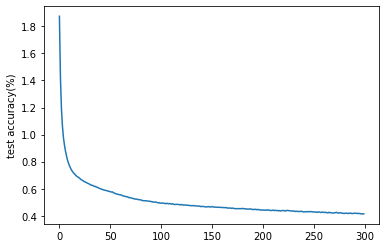

In [7]:
plt.plot(range(len(loss_train[0:300])), loss_train[0:300])
plt.ylabel('test accuracy(%)')
plt.show()

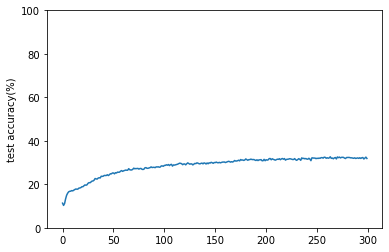

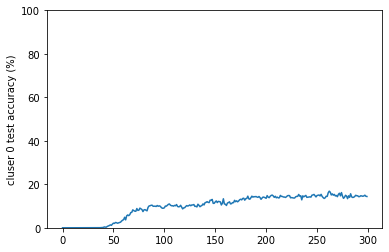

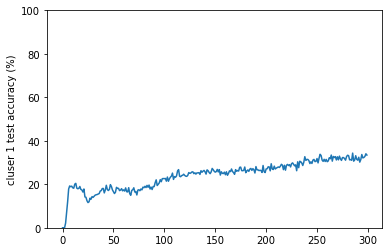

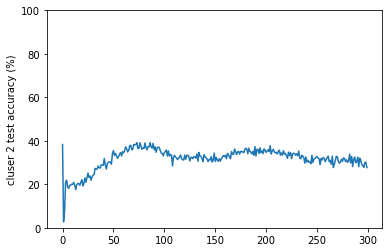

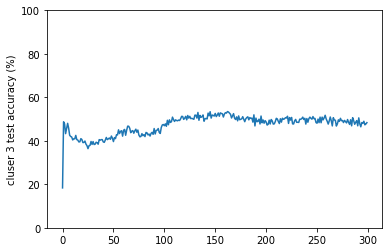

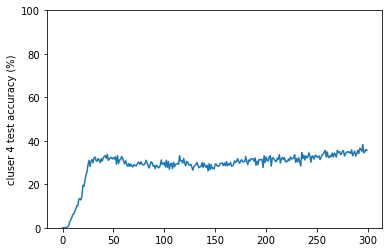

In [14]:
step=300
plt.ylim(0,100)
plt.plot(range(len(acc_test_arr[0:300])), acc_test_arr[0:300])
plt.ylabel('test accuracy(%)')
plt.show()
plt.ylim(0,100)
plt.plot(range(len(cluster_0_acc[0:step])), cluster_0_acc[0:step])
plt.ylabel('cluser 0 test accuracy (%)')
plt.show()
plt.ylim(0,100)
plt.plot(range(len(cluster_1_acc[0:step])), cluster_1_acc[0:step])
plt.ylabel('cluser 1 test accuracy (%)')
plt.show()
plt.ylim(0,100)
plt.plot(range(len(cluster_2_acc[0:step])), cluster_2_acc[0:step])
plt.ylabel('cluser 2 test accuracy (%)')
plt.show()
plt.ylim(0,100)
plt.plot(range(len(cluster_3_acc[0:step])), cluster_3_acc[0:step])
plt.ylabel('cluser 3 test accuracy (%)')
plt.show()
plt.ylim(0,100)
plt.plot(range(len(cluster_4_acc[0:step])), cluster_4_acc[0:step])
plt.ylabel('cluser 4 test accuracy (%)')

plt.show()

In [15]:
cluster_0=[]
cluster_1=[]
cluster_2=[]
cluster_3=[]
cluster_4=[]
acc_test=[]
for i in range(300):
    cluster_0.append(float(cluster_0_acc[i]))
    cluster_1.append(float(cluster_1_acc[i]))
    cluster_2.append(float(cluster_2_acc[i]))
    cluster_3.append(float(cluster_3_acc[i]))
    cluster_4.append(float(cluster_4_acc[i]))
    acc_test.append(float(acc_test_arr[i]))
print(cluster_0)
print("gap")
print(cluster_1)
print("gap")
print(cluster_2)
print("gap")
print(cluster_3)
print("gap")
print(cluster_4)
print("gap")
#print(acc_test)

[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.05000000074505806, 0.0, 0.05000000074505806, 0.10000000149011612, 0.15000000596046448, 0.15000000596046448, 0.4000000059604645, 0.30000001192092896, 0.30000001192092896, 0.6499999761581421, 0.8500000238418579, 1.0499999523162842, 1.350000023841858, 1.149999976158142, 1.7000000476837158, 2.1500000953674316, 2.0, 2.450000047683716, 2.3499999046325684, 2.0999999046325684, 2.25, 2.4000000953674316, 2.5999999046325684, 3.0999999046325684, 3.5, 3.75, 4.849999904632568, 3.6500000953674316, 5.5, 5.900000095367432, 5.599999904632568, 6.0, 7.0, 7.099999904632568, 8.25, 7.900000095367432, 7.650000095367432, 7.599999904632568, 8.850000381469727, 8.0, 8.100000381469727, 9.050000190734863, 8.75, 8.399999618530273, 7.449999809265137, 8.25, 8.350000381469727, 8.050000190734863, 7.800000190734863, 9.399999618530273, 10.05000019

In [ ]:
print(sum(cluster_0))
print(sum(cluster_1))
print(sum(cluster_2))
print(sum(cluster_3))
print(sum(cluster_4))